In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("student_final_marks_dataset.csv")
df

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
0,101,2,65,55,50,54
1,102,3,68,58,55,58
2,103,3,70,60,57,60
3,104,4,72,62,60,63
4,105,4,75,65,62,66
5,106,5,78,68,65,69
6,107,5,80,70,67,71
7,108,6,82,72,70,74
8,109,6,84,75,72,77
9,110,7,85,78,75,80


In [4]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
0,101,2,65,55,50,54
1,102,3,68,58,55,58
2,103,3,70,60,57,60
3,104,4,72,62,60,63
4,105,4,75,65,62,66


In [5]:
df.tail()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
15,116,10,95,90,90,95
16,117,4,76,66,64,67
17,118,6,83,73,71,75
18,119,5,79,69,66,70
19,120,8,91,85,83,88


In [6]:
df.tail()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
15,116,10,95,90,90,95
16,117,4,76,66,64,67
17,118,6,83,73,71,75
18,119,5,79,69,66,70
19,120,8,91,85,83,88


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        20 non-null     int64
 1   Study_Hours       20 non-null     int64
 2   Attendance        20 non-null     int64
 3   Assignment_Score  20 non-null     int64
 4   Previous_Marks    20 non-null     int64
 5   Final_Marks       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [8]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,110.50000,5.950000,81.750000,73.300000,70.900000,75.150000
std,5.91608,2.258901,8.848877,10.533655,11.317895,11.979258
min,101.00000,2.000000,65.000000,55.000000,50.000000,54.000000
25%,105.75000,4.000000,75.750000,65.750000,63.500000,66.750000
50%,110.50000,6.000000,82.500000,72.500000,70.500000,74.500000
75%,115.25000,8.000000,89.250000,82.500000,80.500000,85.500000
max,120.00000,10.000000,95.000000,90.000000,90.000000,95.000000


In [9]:
df.isnull().sum()

Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Previous_Marks      0
Final_Marks         0
dtype: int64

In [10]:
X = df.drop(["Student_ID","Final_Marks"], axis=1)

y = df["Final_Marks"]

In [13]:
X.head()

,Study_Hours,Attendance,Assignment_Score,Previous_Marks
0,2,65,55,50
1,3,68,58,55
2,3,70,60,57
3,4,72,62,60
4,4,75,65,62


In [14]:
y.head()

0    54
1    58
2    60
3    63
4    66
Name: Final_Marks, dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred

array([53.622443  , 75.09441196, 94.8244838 , 58.00096145])

In [20]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison)

    Actual  Predicted
0       54  53.622443
17      75  75.094412
15      95  94.824484
1       58  58.000961


In [22]:
# Model Coefficients
# Purpose:
# Weight (importance) of each feature.

print(model.coef_)

[0.36908908 0.05100292 0.53344325 0.45121817]


In [24]:
# Purpose:

# Constant value (bias).
print(model.intercept_)

-2.331212210537714


In [25]:
# Coefficient Table

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef)

            Feature  Coefficient
0       Study_Hours     0.369089
1        Attendance     0.051003
2  Assignment_Score     0.533443
3    Previous_Marks     0.451218


In [26]:
#Import Evaluation Metrics

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [29]:
# Purpose:
# Average absolute prediction error.
# Lower MAE = Better model

mean_absolute_error(y_test, y_pred)

0.16211165115099568

In [32]:
# Mean Squared Error (MSE)
# Purpose:
# Average squared prediction error.
# Lower MSE = Better model.
    
mean_squared_error(y_test, y_pred)

0.04556744187841441

In [33]:
np.sqrt(mean_squared_error(y_test, y_pred))


# Purpose:

# Error in original unit (marks).

# Lower RMSE = Better model.

np.float64(0.21346531774134742)

In [35]:
# Purpose:

# Measures how well the model explains the data.

# Interpretation:

# 1.0 → Perfect prediction
# 0.9 → Excellent
# 0.8 → Good
# 0 → Poor

r2_score(y_test, y_pred)

0.9998262442635714

In [36]:
new_student = [[7,88,80,78]]

prediction = model.predict(new_student)

print(prediction)

[82.61114558]


C:\Users\Dictator\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


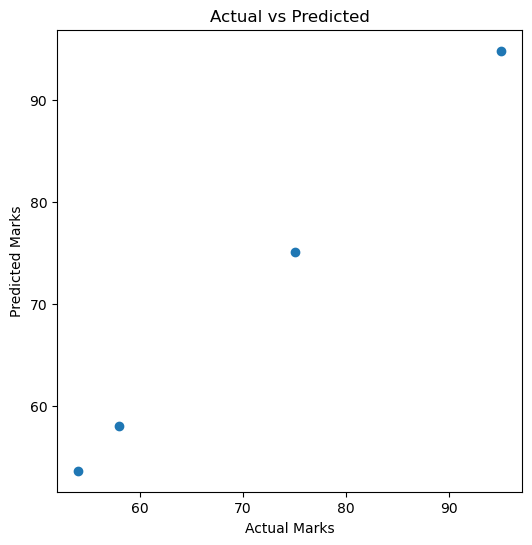

In [37]:
#Scatter Plot (Actual vs Predicted)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

plt.show()

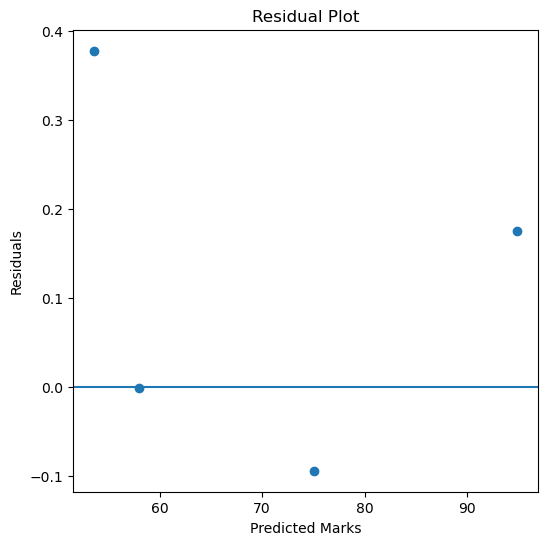

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [39]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

#save a modal

['linear_regression_model.pkl']

In [40]:
loaded_model = joblib.load("linear_regression_model.pkl")

#load a modal

In [41]:
# Predict Using Loaded Model

loaded_model.predict([[8,90,85,82]])

C:\Users\Dictator\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([87.55432942])